In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

x = np.load('/content/drive/MyDrive/alphabet/images_original.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_original.npy')

# لو الصور رمادية، نضيف قناة واحدة
if len(x.shape) == 3:
    x = np.expand_dims(x, axis=-1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

input_shape = x.shape[1:]
num_classes = len(np.unique(y))


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Dense Layers ---
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



--- Run 1 ---
Epoch 1/20
534/534 - 41s - 77ms/step - accuracy: 0.6197 - loss: 1.3178 - val_accuracy: 0.5791 - val_loss: 1.3632
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9512 - loss: 0.1632 - val_accuracy: 0.9856 - val_loss: 0.0546
Epoch 3/20
534/534 - 22s - 41ms/step - accuracy: 0.9792 - loss: 0.0721 - val_accuracy: 0.9877 - val_loss: 0.0438
Epoch 4/20
534/534 - 40s - 75ms/step - accuracy: 0.9855 - loss: 0.0503 - val_accuracy: 0.9875 - val_loss: 0.0470
Epoch 5/20
534/534 - 41s - 77ms/step - accuracy: 0.9890 - loss: 0.0389 - val_accuracy: 0.9884 - val_loss: 0.0396
Epoch 6/20
534/534 - 21s - 39ms/step - accuracy: 0.9898 - loss: 0.0371 - val_accuracy: 0.9872 - val_loss: 0.0479
Epoch 7/20
534/534 - 42s - 78ms/step - accuracy: 0.9868 - loss: 0.0424 - val_accuracy: 0.9906 - val_loss: 0.0343
Epoch 8/20
534/534 - 42s - 78ms/step - accuracy: 0.9924 - loss: 0.0265 - val_accuracy: 0.9915 - val_loss: 0.0300
Epoch 9/20
534/534 - 22s - 41ms/step - accuracy: 0.9913 - loss: 0.0282 - val_accu

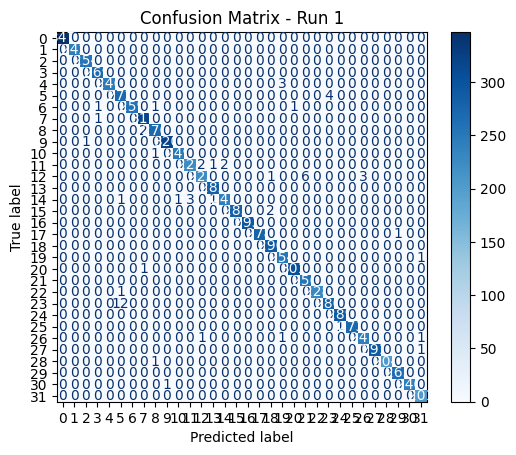

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9926 | ROC AUC: 1.0000
F1 Weighted: 0.9929 | Precision Weighted: 0.9929 | Recall Weighted: 0.9929
Training Time: 720.70s | Memory Used: 250.01 MB

--- Run 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 41s - 76ms/step - accuracy: 0.5814 - loss: 1.4492 - val_accuracy: 0.3977 - val_loss: 1.9979
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9414 - loss: 0.1940 - val_accuracy: 0.9800 - val_loss: 0.0850
Epoch 3/20
534/534 - 42s - 79ms/step - accuracy: 0.9774 - loss: 0.0811 - val_accuracy: 0.9776 - val_loss: 0.0691
Epoch 4/20
534/534 - 22s - 42ms/step - accuracy: 0.9844 - loss: 0.0547 - val_accuracy: 0.9850 - val_loss: 0.0530
Epoch 5/20
534/534 - 41s - 76ms/step - accuracy: 0.9877 - loss: 0.0411 - val_accuracy: 0.9864 - val_loss: 0.0454
Epoch 6/20
534/534 - 42s - 78ms/step - accuracy: 0.9905 - loss: 0.0334 - val_accuracy: 0.9892 - val_loss: 0.0412
Epoch 7/20
534/534 - 41s - 76ms/step - accuracy: 0.9863 - loss: 0.0468 - val_accuracy: 0.9884 - val_loss: 0.0392
Epoch 8/20
534/534 - 23s - 42ms/step - accuracy: 0.9909 - loss: 0.0303 - val_accuracy: 0.9899 - val_loss: 0.0349
Epoch 9/20
534/534 - 40s - 76ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9936 - 

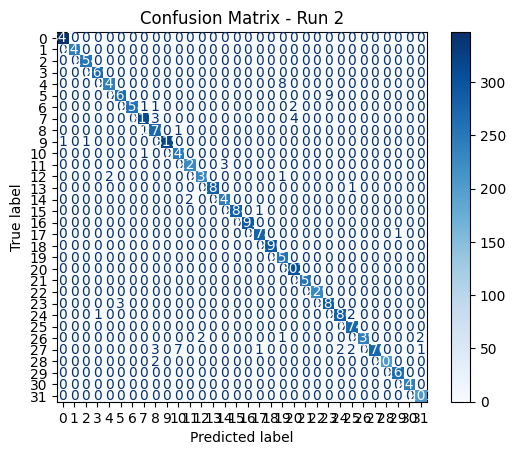

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9912 | ROC AUC: 0.9999
F1 Weighted: 0.9914 | Precision Weighted: 0.9916 | Recall Weighted: 0.9915
Training Time: 684.08s | Memory Used: 269.79 MB

--- Run 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 42s - 78ms/step - accuracy: 0.6466 - loss: 1.2359 - val_accuracy: 0.7533 - val_loss: 0.8046
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9552 - loss: 0.1553 - val_accuracy: 0.9877 - val_loss: 0.0533
Epoch 3/20
534/534 - 41s - 76ms/step - accuracy: 0.9819 - loss: 0.0683 - val_accuracy: 0.9867 - val_loss: 0.0470
Epoch 4/20
534/534 - 21s - 39ms/step - accuracy: 0.9858 - loss: 0.0520 - val_accuracy: 0.9869 - val_loss: 0.0460
Epoch 5/20
534/534 - 40s - 75ms/step - accuracy: 0.9891 - loss: 0.0386 - val_accuracy: 0.9923 - val_loss: 0.0349
Epoch 6/20
534/534 - 21s - 39ms/step - accuracy: 0.9871 - loss: 0.0432 - val_accuracy: 0.9849 - val_loss: 0.0503
Epoch 7/20
534/534 - 42s - 78ms/step - accuracy: 0.9903 - loss: 0.0338 - val_accuracy: 0.9724 - val_loss: 0.0894
Epoch 8/20
534/534 - 41s - 78ms/step - accuracy: 0.9889 - loss: 0.0375 - val_accuracy: 0.9869 - val_loss: 0.0474
Epoch 9/20
534/534 - 41s - 76ms/step - accuracy: 0.9920 - loss: 0.0273 - val_accuracy: 0.9926 - 

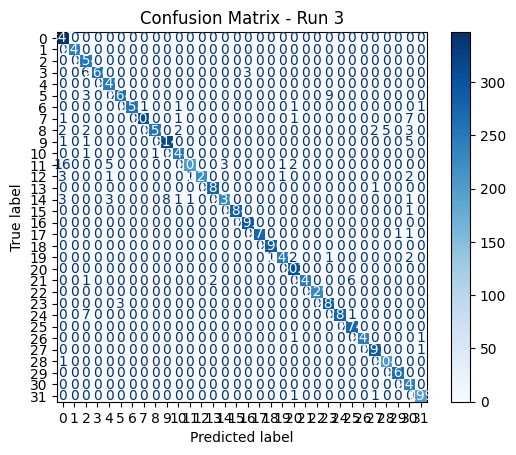

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9821 | ROC AUC: 0.9999
F1 Weighted: 0.9827 | Precision Weighted: 0.9834 | Recall Weighted: 0.9827
Training Time: 718.84s | Memory Used: 204.38 MB

--- Run 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 40s - 76ms/step - accuracy: 0.6110 - loss: 1.3575 - val_accuracy: 0.6376 - val_loss: 1.1403
Epoch 2/20
534/534 - 29s - 54ms/step - accuracy: 0.9491 - loss: 0.1758 - val_accuracy: 0.9854 - val_loss: 0.0588
Epoch 3/20
534/534 - 40s - 75ms/step - accuracy: 0.9790 - loss: 0.0735 - val_accuracy: 0.9893 - val_loss: 0.0435
Epoch 4/20
534/534 - 21s - 39ms/step - accuracy: 0.9862 - loss: 0.0496 - val_accuracy: 0.9890 - val_loss: 0.0442
Epoch 5/20
534/534 - 20s - 38ms/step - accuracy: 0.9878 - loss: 0.0429 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 6/20
534/534 - 20s - 38ms/step - accuracy: 0.9891 - loss: 0.0405 - val_accuracy: 0.9819 - val_loss: 0.0580
Epoch 7/20
534/534 - 21s - 38ms/step - accuracy: 0.9901 - loss: 0.0360 - val_accuracy: 0.9879 - val_loss: 0.0443
Epoch 8/20
534/534 - 41s - 77ms/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 0.9895 - val_loss: 0.0393
Epoch 9/20
534/534 - 41s - 77ms/step - accuracy: 0.9899 - loss: 0.0323 - val_accuracy: 0.9899 - 

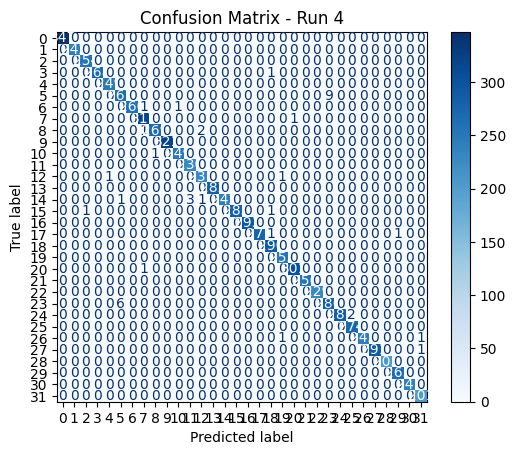

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MCC: 0.9952 | ROC AUC: 1.0000
F1 Weighted: 0.9953 | Precision Weighted: 0.9953 | Recall Weighted: 0.9953
Training Time: 665.62s | Memory Used: 200.42 MB

--- Run 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 42s - 78ms/step - accuracy: 0.6318 - loss: 1.2750 - val_accuracy: 0.6161 - val_loss: 1.2617
Epoch 2/20
534/534 - 25s - 47ms/step - accuracy: 0.9532 - loss: 0.1617 - val_accuracy: 0.9838 - val_loss: 0.0670
Epoch 3/20
534/534 - 21s - 39ms/step - accuracy: 0.9807 - loss: 0.0686 - val_accuracy: 0.9843 - val_loss: 0.0615
Epoch 4/20
534/534 - 41s - 77ms/step - accuracy: 0.9873 - loss: 0.0458 - val_accuracy: 0.9893 - val_loss: 0.0389
Epoch 5/20
534/534 - 21s - 39ms/step - accuracy: 0.9879 - loss: 0.0408 - val_accuracy: 0.9881 - val_loss: 0.0429
Epoch 6/20
534/534 - 22s - 41ms/step - accuracy: 0.9881 - loss: 0.0418 - val_accuracy: 0.9920 - val_loss: 0.0313
Epoch 7/20
534/534 - 20s - 38ms/step - accuracy: 0.9887 - loss: 0.0386 - val_accuracy: 0.9876 - val_loss: 0.0503
Epoch 8/20
534/534 - 21s - 39ms/step - accuracy: 0.9907 - loss: 0.0318 - val_accuracy: 0.9875 - val_loss: 0.0508
Epoch 9/20
534/534 - 22s - 41ms/step - accuracy: 0.9913 - loss: 0.0297 - val_accuracy: 0.9925 - 

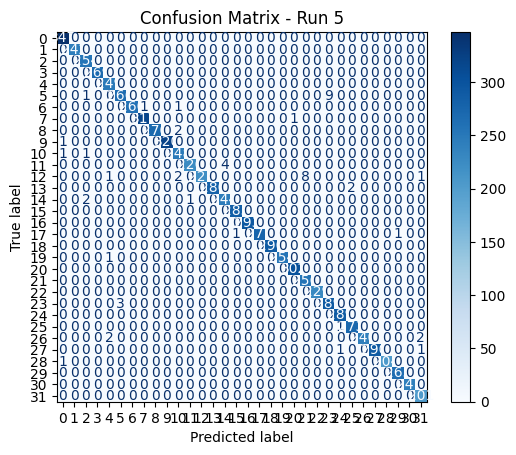

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9936 | ROC AUC: 1.0000
F1 Weighted: 0.9938 | Precision Weighted: 0.9939 | Recall Weighted: 0.9938
Training Time: 644.43s | Memory Used: 262.77 MB

--- Run 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 40s - 75ms/step - accuracy: 0.6016 - loss: 1.3853 - val_accuracy: 0.6636 - val_loss: 1.0798
Epoch 2/20
534/534 - 27s - 51ms/step - accuracy: 0.9462 - loss: 0.1846 - val_accuracy: 0.9795 - val_loss: 0.0706
Epoch 3/20
534/534 - 41s - 76ms/step - accuracy: 0.9780 - loss: 0.0790 - val_accuracy: 0.9860 - val_loss: 0.0506
Epoch 4/20
534/534 - 42s - 79ms/step - accuracy: 0.9855 - loss: 0.0505 - val_accuracy: 0.9860 - val_loss: 0.0522
Epoch 5/20
534/534 - 21s - 39ms/step - accuracy: 0.9860 - loss: 0.0473 - val_accuracy: 0.9905 - val_loss: 0.0345
Epoch 6/20
534/534 - 41s - 76ms/step - accuracy: 0.9871 - loss: 0.0419 - val_accuracy: 0.9847 - val_loss: 0.0569
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9891 - loss: 0.0365 - val_accuracy: 0.9891 - val_loss: 0.0417
Epoch 8/20
534/534 - 40s - 76ms/step - accuracy: 0.9883 - loss: 0.0361 - val_accuracy: 0.9902 - val_loss: 0.0393
Epoch 9/20
534/534 - 43s - 80ms/step - accuracy: 0.9932 - loss: 0.0241 - val_accuracy: 0.9931 - 

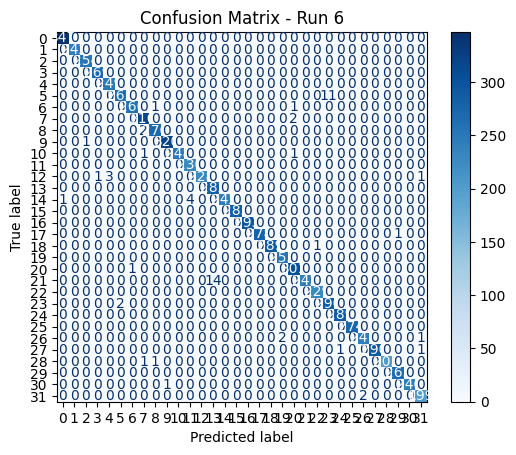

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9929 | ROC AUC: 1.0000
F1 Weighted: 0.9931 | Precision Weighted: 0.9932 | Recall Weighted: 0.9931
Training Time: 706.58s | Memory Used: 133.47 MB

--- Run 7 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 44s - 82ms/step - accuracy: 0.6464 - loss: 1.2184 - val_accuracy: 0.5995 - val_loss: 1.2949
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9534 - loss: 0.1610 - val_accuracy: 0.9835 - val_loss: 0.0609
Epoch 3/20
534/534 - 20s - 38ms/step - accuracy: 0.9818 - loss: 0.0654 - val_accuracy: 0.9857 - val_loss: 0.0494
Epoch 4/20
534/534 - 21s - 39ms/step - accuracy: 0.9856 - loss: 0.0483 - val_accuracy: 0.9892 - val_loss: 0.0368
Epoch 5/20
534/534 - 41s - 77ms/step - accuracy: 0.9885 - loss: 0.0404 - val_accuracy: 0.9869 - val_loss: 0.0447
Epoch 6/20
534/534 - 41s - 77ms/step - accuracy: 0.9898 - loss: 0.0373 - val_accuracy: 0.9829 - val_loss: 0.0683
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9903 - loss: 0.0317 - val_accuracy: 0.9874 - val_loss: 0.0442
Epoch 8/20
534/534 - 41s - 76ms/step - accuracy: 0.9908 - loss: 0.0320 - val_accuracy: 0.9915 - val_loss: 0.0289
Epoch 9/20
534/534 - 21s - 39ms/step - accuracy: 0.9905 - loss: 0.0324 - val_accuracy: 0.9883 - 

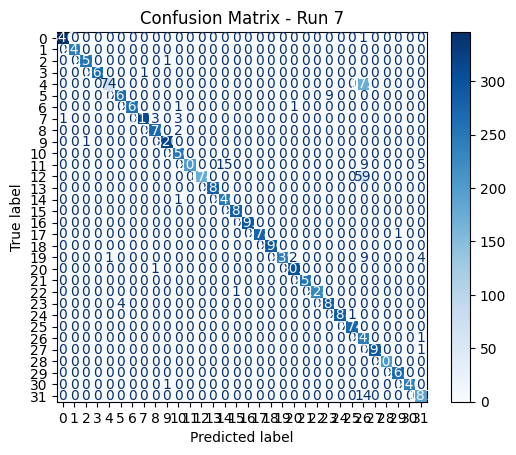

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9610 | ROC AUC: 0.9987
F1 Weighted: 0.9609 | Precision Weighted: 0.9776 | Recall Weighted: 0.9615
Training Time: 640.90s | Memory Used: 170.49 MB

--- Run 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 43s - 80ms/step - accuracy: 0.5972 - loss: 1.3982 - val_accuracy: 0.5428 - val_loss: 1.4513
Epoch 2/20
534/534 - 20s - 38ms/step - accuracy: 0.9474 - loss: 0.1798 - val_accuracy: 0.9842 - val_loss: 0.0666
Epoch 3/20
534/534 - 41s - 77ms/step - accuracy: 0.9808 - loss: 0.0684 - val_accuracy: 0.9861 - val_loss: 0.0528
Epoch 4/20
534/534 - 21s - 39ms/step - accuracy: 0.9871 - loss: 0.0474 - val_accuracy: 0.9851 - val_loss: 0.0527
Epoch 5/20
534/534 - 20s - 38ms/step - accuracy: 0.9880 - loss: 0.0426 - val_accuracy: 0.9920 - val_loss: 0.0320
Epoch 6/20
534/534 - 41s - 76ms/step - accuracy: 0.9849 - loss: 0.0477 - val_accuracy: 0.9792 - val_loss: 0.0741
Epoch 7/20
534/534 - 22s - 41ms/step - accuracy: 0.9891 - loss: 0.0393 - val_accuracy: 0.9849 - val_loss: 0.0522
Epoch 8/20
534/534 - 39s - 73ms/step - accuracy: 0.9908 - loss: 0.0327 - val_accuracy: 0.9911 - val_loss: 0.0375
Epoch 9/20
534/534 - 21s - 39ms/step - accuracy: 0.9936 - loss: 0.0233 - val_accuracy: 0.9939 - 

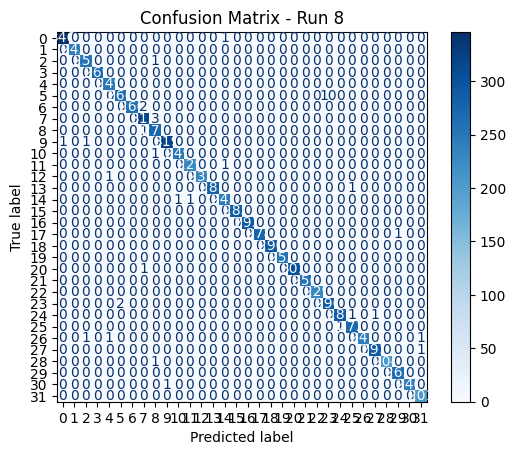

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9953 | ROC AUC: 1.0000
F1 Weighted: 0.9954 | Precision Weighted: 0.9955 | Recall Weighted: 0.9954
Training Time: 579.56s | Memory Used: 268.55 MB

--- Run 9 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 44s - 82ms/step - accuracy: 0.6321 - loss: 1.2696 - val_accuracy: 0.5479 - val_loss: 1.3898
Epoch 2/20
534/534 - 25s - 46ms/step - accuracy: 0.9506 - loss: 0.1677 - val_accuracy: 0.9813 - val_loss: 0.0709
Epoch 3/20
534/534 - 41s - 77ms/step - accuracy: 0.9793 - loss: 0.0732 - val_accuracy: 0.9877 - val_loss: 0.0470
Epoch 4/20
534/534 - 41s - 77ms/step - accuracy: 0.9853 - loss: 0.0540 - val_accuracy: 0.9871 - val_loss: 0.0510
Epoch 5/20
534/534 - 41s - 77ms/step - accuracy: 0.9874 - loss: 0.0444 - val_accuracy: 0.9827 - val_loss: 0.0613
Epoch 6/20
534/534 - 41s - 76ms/step - accuracy: 0.9891 - loss: 0.0382 - val_accuracy: 0.9861 - val_loss: 0.0472
Epoch 7/20
534/534 - 41s - 77ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9895 - val_loss: 0.0438
Epoch 8/20
534/534 - 41s - 77ms/step - accuracy: 0.9900 - loss: 0.0344 - val_accuracy: 0.9882 - val_loss: 0.0451
Epoch 9/20
534/534 - 41s - 77ms/step - accuracy: 0.9913 - loss: 0.0294 - val_accuracy: 0.9915 - 

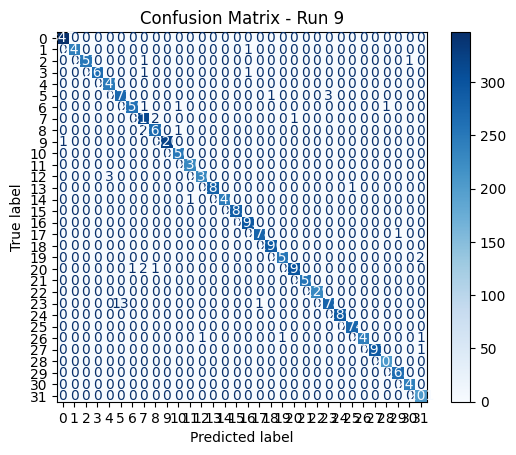

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MCC: 0.9941 | ROC AUC: 1.0000
F1 Weighted: 0.9943 | Precision Weighted: 0.9943 | Recall Weighted: 0.9943
Training Time: 747.85s | Memory Used: 132.44 MB

--- Run 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
534/534 - 44s - 82ms/step - accuracy: 0.6344 - loss: 1.2785 - val_accuracy: 0.6946 - val_loss: 0.9910
Epoch 2/20
534/534 - 21s - 39ms/step - accuracy: 0.9528 - loss: 0.1575 - val_accuracy: 0.9868 - val_loss: 0.0557
Epoch 3/20
534/534 - 41s - 76ms/step - accuracy: 0.9813 - loss: 0.0674 - val_accuracy: 0.9891 - val_loss: 0.0396
Epoch 4/20
534/534 - 42s - 79ms/step - accuracy: 0.9883 - loss: 0.0446 - val_accuracy: 0.9881 - val_loss: 0.0441
Epoch 5/20
534/534 - 22s - 41ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9865 - val_loss: 0.0517
Epoch 6/20
534/534 - 20s - 38ms/step - accuracy: 0.9894 - loss: 0.0366 - val_accuracy: 0.9911 - val_loss: 0.0342
Epoch 7/20
534/534 - 21s - 39ms/step - accuracy: 0.9909 - loss: 0.0334 - val_accuracy: 0.9759 - val_loss: 0.0836
Epoch 8/20
534/534 - 21s - 39ms/step - accuracy: 0.9886 - loss: 0.0364 - val_accuracy: 0.9862 - val_loss: 0.0516
Epoch 9/20
534/534 - 42s - 79ms/step - accuracy: 0.9905 - loss: 0.0314 - val_accuracy: 0.9909 - 

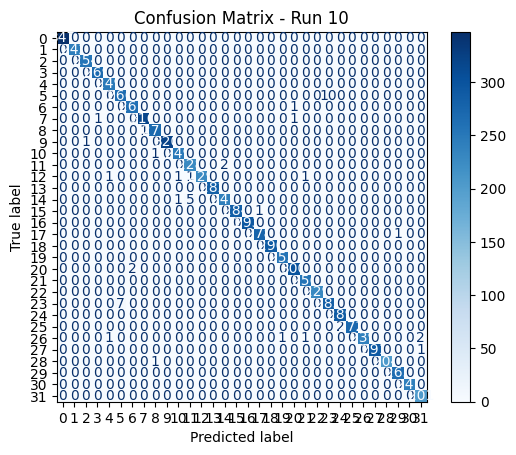

267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9942 | ROC AUC: 1.0000
F1 Weighted: 0.9944 | Precision Weighted: 0.9944 | Recall Weighted: 0.9944
Training Time: 685.93s | Memory Used: 249.22 MB
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.992860  0.027901  0.992629  0.999979     0.992856   
1    2      0.991456  0.041532  0.991181  0.999923     0.991446   
2    3      0.982678  0.065112  0.982135  0.999920     0.982659   
3    4      0.995318  0.019994  0.995166  0.999988     0.995318   
4    5      0.993797  0.022228  0.993597  0.999974     0.993788   
5    6      0.993095  0.025715  0.992873  0.999974     0.993089   
6    7      0.961493  0.304745  0.960954  0.998694     0.960867   
7    8      0.995435  0.019365  0.995287  0.999991     0.995438   
8    9      0.994265  0.022638  0.994079  0.999985     0.994264   
9   10      0.994382  0.024168  0.994199  0.999960     0.994380   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Use

In [5]:
import time
import psutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

num_runs = 10
results = []

for run in range(1, num_runs+1):
    print(f"\n--- Run {run} ---")

    # --- Start measuring memory & time ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    model = build_cnn()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=2
    )

    # --- End measuring memory & time ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)

    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")

    # --- Predictions ---
    y_pred = np.argmax(model.predict(x_val), axis=1)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model.predict(x_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')

    # --- Weighted metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    print(f"MCC: {mcc:.4f} | ROC AUC: {roc_auc:.4f}")
    print(f"F1 Weighted: {f1_w:.4f} | Precision Weighted: {precision_w:.4f} | Recall Weighted: {recall_w:.4f}")
    print(f"Training Time: {train_time:.2f}s | Memory Used: {train_memory:.2f} MB")

    # --- Store all metrics ---
    results.append({
        'Run': run,
        'Val_Accuracy': val_acc,
        'Val_Loss': val_loss,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'F1_Weighted': f1_w,
        'Precision_Weighted': precision_w,
        'Recall_Weighted': recall_w,
        'Training_Time(s)': train_time,
        'Memory_Used(MB)': train_memory
    })

# --- Convert to DataFrame & save ---
df_metrics = pd.DataFrame(results)
print(df_metrics)
df_metrics.to_excel("all_metrics_10runs_with_time_memory.xlsx", index=False)
print("Saved all metrics with time & memory for 10 runs to all_metrics_10runs_with_time_memory.xlsx")


In [6]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_runs_analysis_Original.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.992860  0.027901  0.992629  0.999979     0.992856   
1    2      0.991456  0.041532  0.991181  0.999923     0.991446   
2    3      0.982678  0.065112  0.982135  0.999920     0.982659   
3    4      0.995318  0.019994  0.995166  0.999988     0.995318   
4    5      0.993797  0.022228  0.993597  0.999974     0.993788   
5    6      0.993095  0.025715  0.992873  0.999974     0.993089   
6    7      0.961493  0.304745  0.960954  0.998694     0.960867   
7    8      0.995435  0.019365  0.995287  0.999991     0.995438   
8    9      0.994265  0.022638  0.994079  0.999985     0.994264   
9   10      0.994382  0.024168  0.994199  0.999960     0.994380   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.992925         0.992860        720.699108       250.007812  
1            0.991586         0.991456        684.075694       269.7


📊 Average Results across all runs:
Average Accuracy : 0.9895
Average Loss     : 0.0573
Average MCC      : 0.9892
Average ROC AUC  : 0.9998

✅ Results saved to /content/drive/MyDrive/alphabet/CNN_runs_results_Original.xlsx


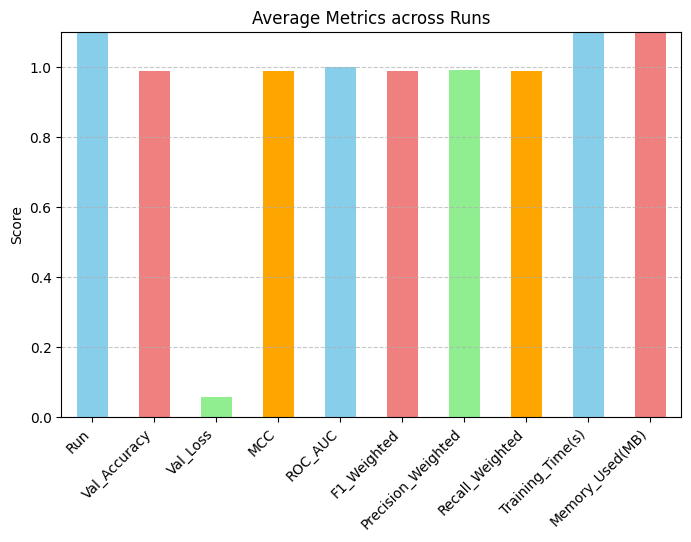

In [7]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss     : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC      : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC  : {avg_results['ROC_AUC']:.4f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/alphabet/CNN_runs_results_Original.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات ---
plt.figure(figsize=(8,5))
avg_results.plot(kind='bar', color=['skyblue','lightcoral','lightgreen','orange'])
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e324240a33c92a9e46eb9002aa9f2a331f58670de006648435148eb9a3ce03ca
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Input Shape: 64x64x1


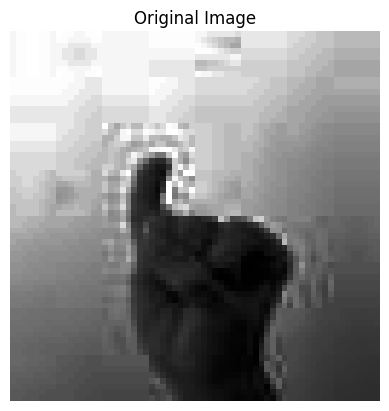

Predicted class: meem (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

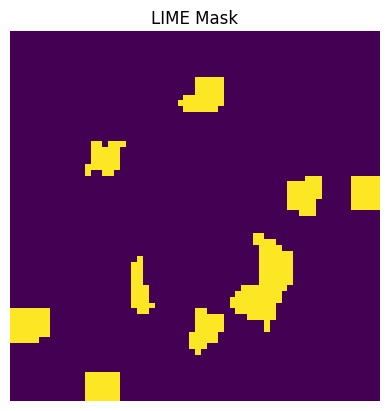

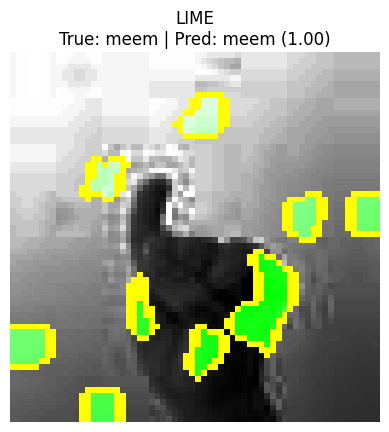

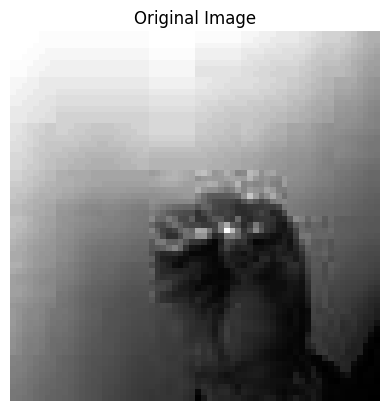

Predicted class: ha (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

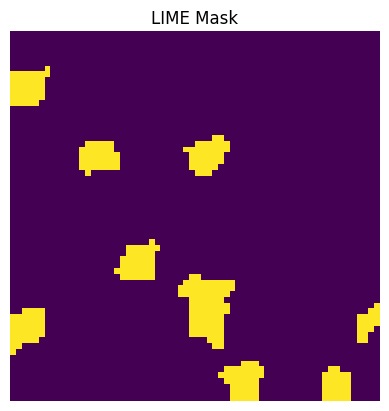

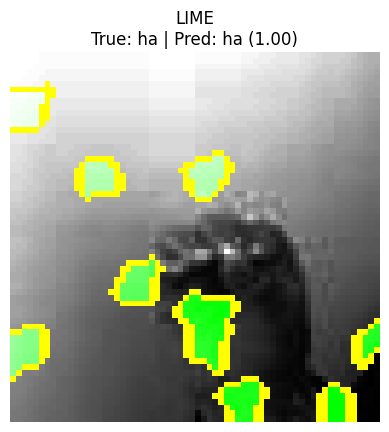

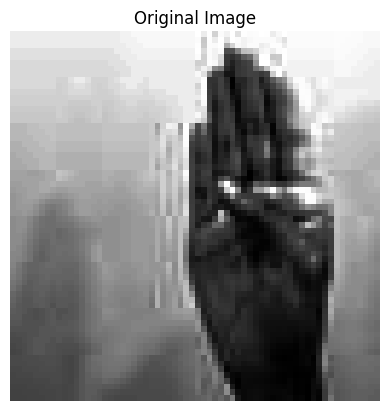

Predicted class: kaaf (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

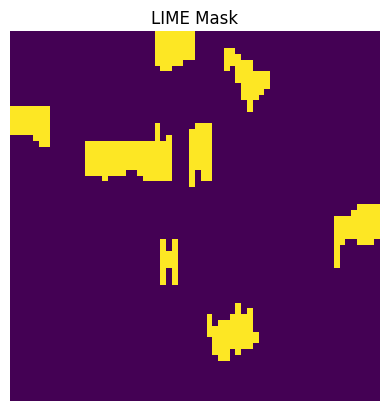

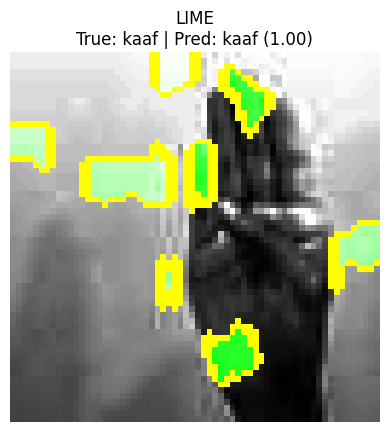

In [8]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
H, W, C = model.input_shape[1:]
print(f"📐 Input Shape: {H}x{W}x{C}")

# دالة تجهيز الصور زي التدريب
def preprocess_batch(images):
    out = []
    for im in images:
        im = np.asarray(im)
        if im.ndim == 2:  # صورة رمادية
            im = np.repeat(im[..., np.newaxis], 3, axis=-1)
            im = np.squeeze(im)
        elif im.shape[-1] == 1 and C == 3:
            im = np.repeat(im, 3, axis=-1)
            im = np.squeeze(im)
        # تغيير الحجم لتوافق مدخلات الموديل
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype('float32')
        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(x_val), size=3, replace=False)

for idx in indices:
    image = x_val[idx]

    # تجهيز نسخة RGB للعرض
    if image.ndim == 2 or image.shape[-1] == 1:
        image_rgb = np.repeat(image[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = image
    image_rgb = image_rgb[..., :3]

    # --- عرض الصورة الأصلية ---
    plt.figure()
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask)
    plt.title("LIME Mask")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()


In [9]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/alphabet/my_modelcnn_Original.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_cnn_original.npy', x_val)
np.save('/content/drive/MyDrive/alphabet/y_val_cnn_original.npy', y_val)
